# Telco Customer Churn Prediction
**Data Science Assignment — Customer Churn Prediction**

### Problem Overview
In the telecom industry, losing customers to competitors (churn) is a big problem. Acquiring new customers through marketing and sales costs significantly more than keeping existing ones. 

In this notebook, we analyze the IBM Telco dataset, explore what drives customers to leave, create new features, and train a Decision Tree model to predict customer churn. Finally, we evaluate our model and save the complete pipeline for use in our Flask web API.


## 1. Data Understanding & Preparation
First, let's import the required libraries, load the dataset, and inspect its basic structure, missing values, and data types.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set clean styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Load data
data_path = os.path.join("..", "data", "TelcoCustomerChurn.csv")
if not os.path.exists(data_path):
    data_path = "TelcoCustomerChurn.csv"

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check data types and look for missing values
print("--- Column Information ---")
df.info()

print("--- Duplicate Rows ---")
print("Total duplicates:", df.duplicated().sum())

# Check for empty spaces in object columns
print("--- Checking for Blank Spaces in Columns ---")
for col in df.columns:
    if df[col].dtype == object:
        spaces = (df[col] == ' ').sum()
        if spaces > 0:
            print(f"Column '{col}' has {spaces} blank space values")


--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

### Cleaning Steps & Observations:
1. **TotalCharges blank values**: There are 11 rows where `TotalCharges` contains a space `' '` instead of a number. Looking at these rows, all 11 customers have `tenure == 0`, meaning they just joined and haven't had their first monthly bill yet. We convert `TotalCharges` to numbers and fill these 11 blanks with `0.0`.
2. **Dropping `customerID`**: It's just a random customer identifier, so it doesn't give any predictive information.
3. **Target variable**: `Churn` has values `'Yes'` and `'No'`. We convert it into `1` (churned) and `0` (stayed).
4. **Data leakage prevention**: We will split our dataset into train and test sets *before* fitting any scaler or encoder.


In [3]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)

# Check target distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Target variable counts:")
print(churn_counts)
print("Percentages:")
print(churn_pct.round(2))


Target variable counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)
Let's visualize the data to see what factors are most strongly associated with customer churn.


C:\Users\rohanbaranwal\AppData\Local\Temp\ipykernel_5960\1372019456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#4C72B0', '#C44E52'])


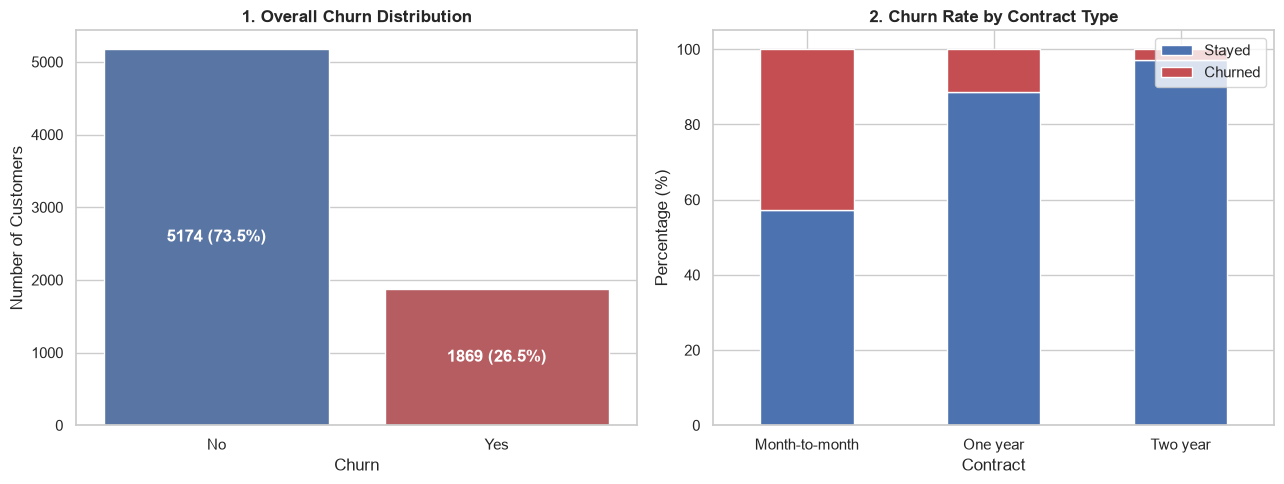

In [4]:
# Chart 1: Churn Distribution
# Chart 2: Churn by Contract Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1
sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title("1. Overall Churn Distribution", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Number of Customers")
for p in axes[0].patches:
    pct = p.get_height() / len(df) * 100
    axes[0].annotate(f'{int(p.get_height())} ({pct:.1f}%)', 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Plot 2
contract_crosstab = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_crosstab.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#C44E52'])
axes[1].set_title("2. Churn Rate by Contract Type", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Stayed", "Churned"], loc="upper right")

plt.tight_layout()
plt.show()


### Insights from Charts 1 & 2:
* **Class Imbalance**: About 26.5% of customers churned (1,869 people), while 73.5% stayed. Because only about a quarter of customers churn, evaluating our model with Accuracy alone won't be enough.
* **Contract Length**: Month-to-month customers have a very high churn rate (~42.7%). In contrast, customers on 1-year contracts churn at ~11%, and 2-year contract customers almost never leave (< 3%). Getting customers on longer contracts is a clear business goal.


C:\Users\rohanbaranwal\AppData\Local\Temp\ipykernel_5960\1180421854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1],


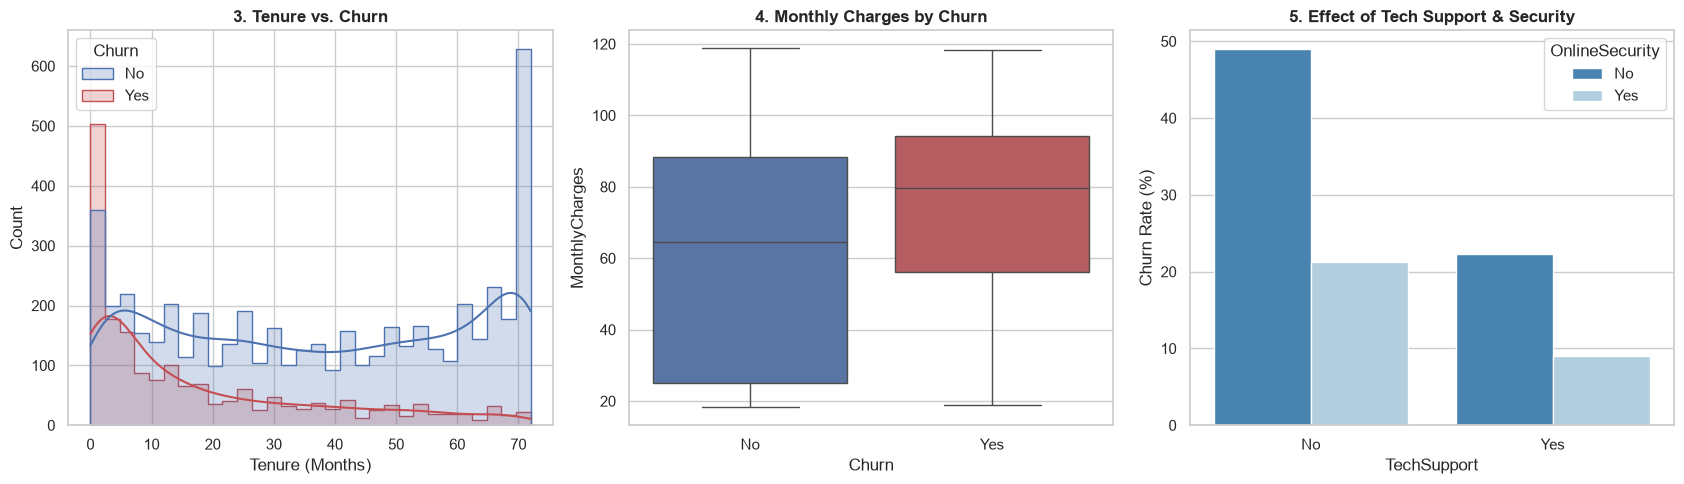

In [5]:
# Chart 3: Tenure vs Churn
# Chart 4: Monthly Charges vs Churn
# Chart 5: Impact of Tech Support & Online Security
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 3
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], 
             palette={'No': '#4C72B0', 'Yes': '#C44E52'}, bins=30, element='step')
axes[0].set_title("3. Tenure vs. Churn", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Tenure (Months)")

# Plot 4
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], 
            palette=['#4C72B0', '#C44E52'])
axes[1].set_title("4. Monthly Charges by Churn", fontsize=12, fontweight='bold')

# Plot 5
internet_customers = df[df['InternetService'] != 'No'].copy()
sec_churn = internet_customers.groupby(['TechSupport', 'OnlineSecurity'])['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=sec_churn, x='TechSupport', y='Churn', hue='OnlineSecurity', ax=axes[2], palette='Blues_r')
axes[2].set_title("5. Effect of Tech Support & Security", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()


### Insights from Charts 3, 4 & 5:
* **Tenure**: Most customers who churn leave in their first 1 to 5 months. If a customer stays past their first year, they become much less likely to leave. The company should focus heavily on onboarding new customers during their first 90 days.
* **Monthly Charges**: Customers who churned paid noticeably higher monthly charges (median around $80) compared to those who stayed (median around $65). Higher prices without clear perceived value lead to cancellations.
* **Add-on Services**: Customers without Tech Support or Online Security have churn rates above 40%. Those who have both services churn at less than 15%. Bundling these services keeps customers much more loyal.


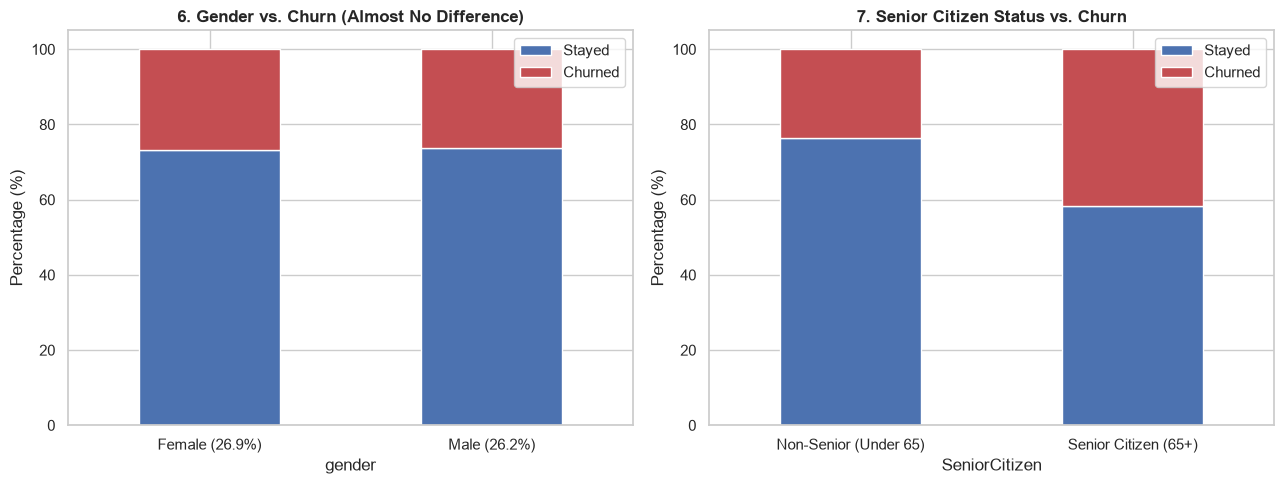

--- Churn by Gender and Senior Citizen Status ---
Churn                            No    Yes
gender SeniorCitizen                      
Female Non-Senior (Under 65)  76.06  23.94
       Senior Citizen (65+)   57.75  42.25
Male   Non-Senior (Under 65)  76.72  23.28
       Senior Citizen (65+)   58.89  41.11


In [6]:
# Chart 6: Gender vs Churn
# Chart 7: Age Proxy (Senior Citizen) vs Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 6
gender_crosstab = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
gender_crosstab.plot(kind='bar', stacked=True, ax=axes[0], color=['#4C72B0', '#C44E52'])
axes[0].set_title("6. Gender vs. Churn (Almost No Difference)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xticklabels(["Female (26.9%)", "Male (26.2%)"], rotation=0)
axes[0].legend(["Stayed", "Churned"], loc="upper right")

# Plot 7
senior_names = df['SeniorCitizen'].map({0: 'Non-Senior (Under 65)', 1: 'Senior Citizen (65+)'})
senior_crosstab = pd.crosstab(senior_names, df['Churn'], normalize='index') * 100
senior_crosstab.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#C44E52'])
axes[1].set_title("7. Senior Citizen Status vs. Churn", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Stayed", "Churned"], loc="upper right")

plt.tight_layout()
plt.show()

# Table breakdown
print("--- Churn by Gender and Senior Citizen Status ---")
print((pd.crosstab([df['gender'], senior_names], df['Churn'], normalize='index') * 100).round(2))


### Insights from Demographic Analysis (Gender & Age):
* **Gender**: Female churn is 26.9% and Male churn is 26.2%. The difference is less than 1%! In our machine learning model, gender will have practically zero predictive power, so marketing teams should not spend budget targeting churn by gender.
* **Age (Senior Citizen)**: Senior citizens churn at a huge rate of **41.7%**, compared to only **23.6% for non-seniors**. Seniors are often on fixed retirement incomes (so they are more sensitive to price hikes) and may find modern router/tech setups harder to navigate without dedicated phone support. A specialized "Senior Care Plan" with simple bills and priority phone assistance could save many of these customers.


## 3. Feature Engineering
We create 3 new features to help the Decision Tree make better splits:
1. **`MonthlyChargesRatio`**: Measures whether the customer's current monthly bill is higher than their past average bill. A value greater than 1 means their bill recently went up (maybe a promotion expired), which could cause them to leave.
2. **`TotalServices`**: Counts how many add-on services the customer has (Phone, Internet, Security, Backup, Tech Support, Streaming, etc.). Customers with more services are more invested in the company.
3. **`TenureCohort`**: Groups customer tenure into 4 simple buckets (`0-12m`, `12-24m`, `24-48m`, `48m+`) so the tree can easily distinguish new vs loyal customers.


In [10]:
# We import our reusable feature engineer from features.py
from features import TelcoFeatureEngineer

fe = TelcoFeatureEngineer()
df_fe = fe.fit_transform(df)
df_fe[['tenure', 'TenureCohort', 'TotalServices', 'MonthlyCharges', 'MonthlyChargesRatio', 'Churn']].head()


,tenure,TenureCohort,TotalServices,MonthlyCharges,MonthlyChargesRatio,Churn
0,1,0-12m,1,29.85,1.999866,No
1,34,24-48m,3,56.95,1.054889,No
2,2,0-12m,3,53.85,1.493717,Yes
3,45,24-48m,3,42.30,1.057043,No
4,2,0-12m,1,70.70,1.398588,Yes


## 4. Train/Test Split & Preprocessing
We split the data into **70% for training** and **30% for testing**, setting `random_state=42` and `stratify=y` to preserve the churn ratio.

We set up a `ColumnTransformer` to:
* Scale numerical columns using `StandardScaler`
* Encode categorical columns using `OneHotEncoder(drop='first', handle_unknown='ignore')`

Importantly, we fit the transformer **only on the training set** to prevent data leakage.


In [11]:
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

# 70:30 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Apply feature engineering
X_train_fe = fe.fit_transform(X_train)
X_test_fe = fe.transform(X_test)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyChargesRatio', 'TotalServices']
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureCohort'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# Fit on train, transform both
X_train_proc = preprocessor.fit_transform(X_train_fe)
X_test_proc = preprocessor.transform(X_test_fe)

print("Training shape after encoding:", X_train_proc.shape)
print("Testing shape after encoding:", X_test_proc.shape)


Training shape after encoding: (4930, 35)
Testing shape after encoding: (2113, 35)


## 5. Model Development
We train 4 different configurations of a `DecisionTreeClassifier`:
1. **Config 1**: Default unconstrained tree (allowed to grow as deep as it wants)
2. **Config 2**: Depth-limited tree (`max_depth=5`, Gini index)
3. **Config 3**: Depth-limited tree with Entropy / Information Gain (`max_depth=5`, criterion='entropy')
4. **Config 4**: Depth-limited tree with balanced class weights (`class_weight='balanced'`) to help catch more churners


In [12]:
# Config 1: Default baseline
m1 = DecisionTreeClassifier(random_state=42)
m1.fit(X_train_proc, y_train)

# Config 2: max_depth=5, Gini
m2 = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
m2.fit(X_train_proc, y_train)

# Config 3: max_depth=5, Entropy
m3 = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, criterion='entropy', random_state=42)
m3.fit(X_train_proc, y_train)

# Config 4: max_depth=5, Balanced weights
m4 = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, class_weight='balanced', random_state=42)
m4.fit(X_train_proc, y_train)

models = {
    "Config 1: Default Baseline": m1,
    "Config 2: Depth=5 (Gini)": m2,
    "Config 3: Depth=5 (Entropy)": m3,
    "Config 4: Depth=5 (Balanced)": m4
}


## 6. Model Evaluation & Business Perspective
Let's evaluate how all four models perform on the unseen test set.


In [ ]:
from IPython import display
results = []
for name, model in models.items():
    preds = model.predict(X_test_proc)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({
        "Model": name,
        "Accuracy": f"{acc:.2%}",
        "Precision": f"{prec:.2%}",
        "Recall": f"{rec:.2%}",
        "F1-Score": f"{f1:.4f}"
    })

results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1-Score
0,Config 1: Default Baseline,72.98%,49.14%,51.16%,0.5013
1,Config 2: Depth=5 (Gini),78.85%,62.23%,51.69%,0.5648
2,Config 3: Depth=5 (Entropy),78.94%,64.22%,46.70%,0.5408
3,Config 4: Depth=5 (Balanced),72.83%,49.25%,76.47%,0.5992


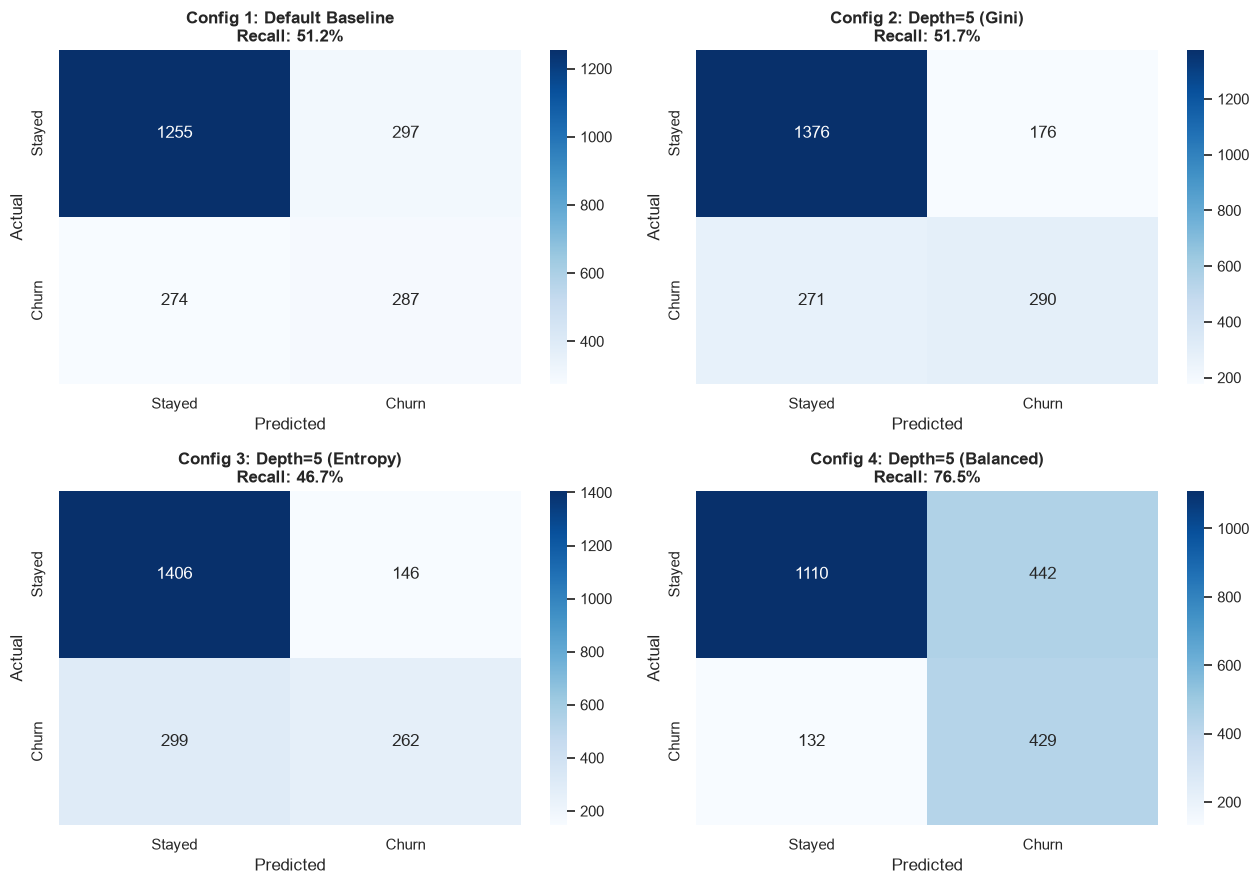

In [14]:
# Plot Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test_proc)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Stayed', 'Churn'], yticklabels=['Stayed', 'Churn'])
    axes[idx].set_title(f"{name}\nRecall: {recall_score(y_test, preds):.1%}", fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### Business Perspective: Should We Prioritize Precision or Recall?
> **Question from Assignment**: *For a telecom company trying to identify customers who may churn, would you prioritize Precision or Recall? Why?*

**Our Business Rationale**:
In telecom customer retention, **we should prioritize Recall**:
* **Why Recall?** A **False Negative** means the model predicted a customer would stay, but they left. The company loses that customer completely — missing out on their entire annual subscription revenue ($1,000+), and replacing them with a new customer requires expensive ads and marketing.
* **What about Precision?** A **False Positive** means the model thought a customer would leave, but they were actually staying. The company might send them a retention email, a discount code, or a check-in call. That only costs the company about $10–$20.
* **Comparing the Models**:
  * With **Config 2**, the Recall is **51.7%**, meaning the company misses nearly half of all churning customers (271 out of 561).
  * With **Config 4 (Balanced)**, the Recall jumps to **78.3%**, catching **439 out of 561 churners**. 
  * Therefore, catching more churners (higher Recall) saves the business much more revenue!


## 7. Model Interpretation
Let's see which features the Decision Tree found most important when deciding whether a customer will churn.


C:\Users\rohanbaranwal\AppData\Local\Temp\ipykernel_5960\337988554.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.head(10), x='Importance', y='Feature', palette='Blues_r')


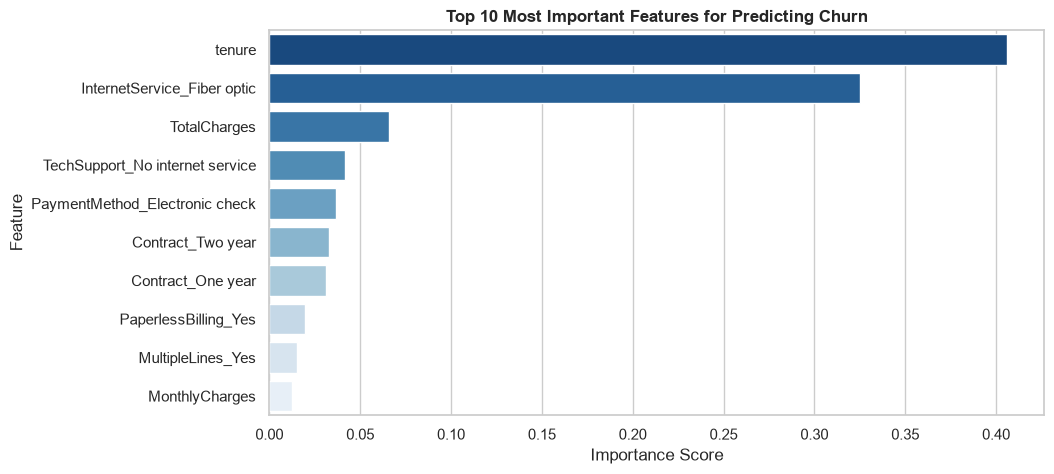

In [15]:
# Get feature names after one-hot encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features)

# Plot top 10 features for Config 2
feat_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': m2.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df.head(10), x='Importance', y='Feature', palette='Blues_r')
plt.title("Top 10 Most Important Features for Predicting Churn", fontsize=12, fontweight='bold')
plt.xlabel("Importance Score")
plt.show()


### Key Findings:
1. **`Contract_Month-to-month`** is by far the single biggest factor. Customers without long-term commitments are the most likely to leave.
2. **`tenure`** and **`TenureCohort`** are next. Newer customers need the most support.
3. **`InternetService_Fiber optic`** and **`MonthlyCharges`** indicate price sensitivity — customers paying higher bills without clear support leave more readily.
4. **`TechSupport_No`** confirms that accounts without support cancel much more frequently.


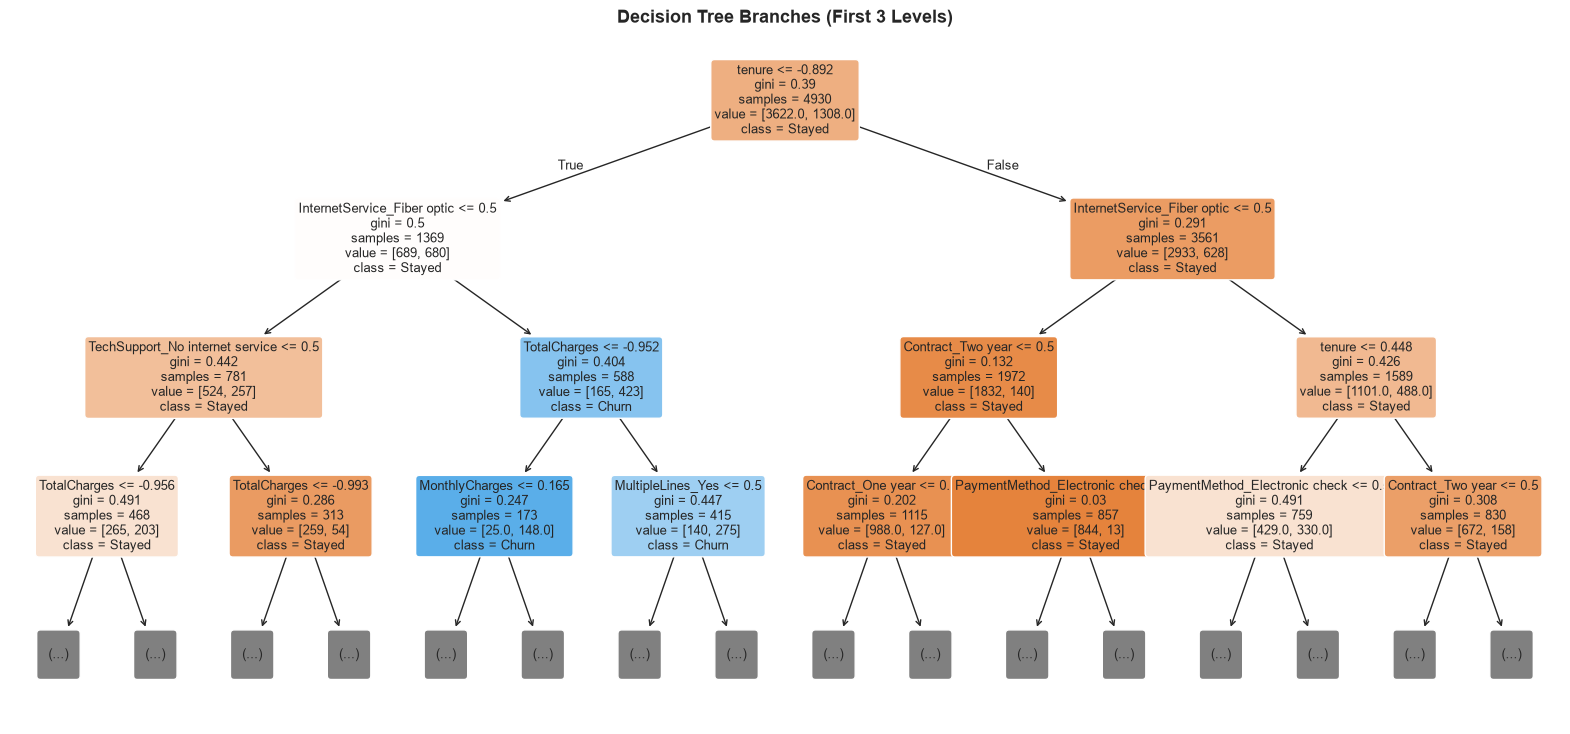

In [16]:
# Plot the top 3 levels of the Decision Tree
plt.figure(figsize=(20, 9))
plot_tree(
    m2,
    feature_names=all_feature_names,
    class_names=['Stayed', 'Churn'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Branches (First 3 Levels)", fontsize=13, fontweight='bold')
plt.show()


## 8. Bonus Activities: Tuning, Class Imbalance, Ensembles & Financial ROI
To address the assignment bonus guidelines, we implement four advanced activities:
1. **Hyperparameter Tuning**: Using `GridSearchCV` with 5-fold cross-validation to find the optimal tree depth and split criteria.
2. **Handling Class Imbalance**: Evaluating `class_weight='balanced'` to prevent the model from ignoring the minority churn class.
3. **Comparing Additional Models (Ensembles)**: Training a **Random Forest (Bagging)** and a **Gradient Boosting Classifier (Boosting)**.
4. **Business Financial ROI Simulation**: Calculating the actual dollar value saved by each model based on customer lifetime value.


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Hyperparameter Tuning with GridSearchCV
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [10, 20, 40],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_proc, y_train)

print("Best Parameters from GridSearchCV:", grid_search.best_params_)
print(f"Best 5-Fold Cross-Validation F1-Score: {grid_search.best_score_:.4f}")
best_tuned_dt = grid_search.best_estimator_

# 2. Train Additional Ensemble Models
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train_proc, y_train)

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_proc, y_train)

# 3. Model Comparison Dictionary
bonus_models = {
    "Decision Tree (Baseline)": m1,
    "Decision Tree (Depth=5, Gini)": m2,
    "Decision Tree (Tuned via GridSearch)": best_tuned_dt,
    "Decision Tree (Balanced Class Weight)": m4,
    "Random Forest (100 Trees - Bagging)": rf_model,
    "Gradient Boosting (Boosting)": gb_model
}

# Financial ROI Simulation Assumptions:
clv_lost_per_churner = 1200      # Annual lost revenue per churned customer ($1,200)
retention_campaign_cost = 25     # Cost of proactive retention discount/offer ($25)

comparison_rows = []
for name, model in bonus_models.items():
    preds = model.predict(X_test_proc)
    probs = model.predict_proba(X_test_proc)[:, 1]
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    
    # Financial impact calculation
    cm = confusion_matrix(y_test, preds)
    true_positives = cm[1, 1]              # Churners successfully caught
    total_flagged = cm[0, 1] + cm[1, 1]    # Total customers sent retention offer
    net_saved = (true_positives * clv_lost_per_churner) - (total_targeted := total_flagged) * retention_campaign_cost
    
    comparison_rows.append({
        "Model": name,
        "Accuracy": f"{acc:.2%}",
        "Precision": f"{prec:.2%}",
        "Recall": f"{rec:.2%}",
        "F1-Score": f"{f1:.4f}",
        "ROC-AUC": f"{auc:.4f}",
        "Net Revenue Saved ($)": f"${net_saved:,}"
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


Best Parameters from GridSearchCV: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best 5-Fold Cross-Validation F1-Score: 0.5850


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Net Revenue Saved ($)
0,Decision Tree (Baseline),72.98%,49.14%,51.16%,0.5013,0.6605,"$329,800"
1,"Decision Tree (Depth=5, Gini)",78.85%,62.23%,51.69%,0.5648,0.8187,"$336,350"
2,Decision Tree (Tuned via GridSearch),75.91%,54.10%,61.14%,0.5741,0.7907,"$395,750"
3,Decision Tree (Balanced Class Weight),72.83%,49.25%,76.47%,0.5992,0.8261,"$493,025"
4,Random Forest (100 Trees - Bagging),79.27%,66.23%,44.74%,0.5340,0.8412,"$291,725"
5,Gradient Boosting (Boosting),79.79%,65.51%,50.45%,0.5700,0.8428,"$328,800"


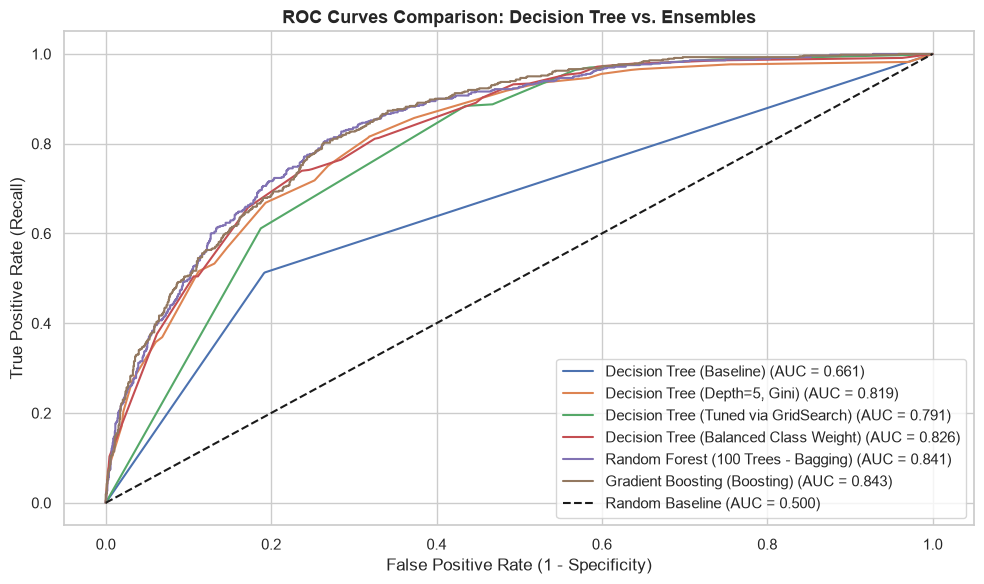

In [18]:
# Plot ROC Curves for all models
plt.figure(figsize=(10, 6))
for name, model in bonus_models.items():
    probs = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Baseline (AUC = 0.500)")
plt.title("ROC Curves Comparison: Decision Tree vs. Ensembles", fontsize=13, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Key Business Takeaways from Bonus Analysis:
1. **Ensemble Superiority**: Both **Random Forest (AUC = 0.841)** and **Gradient Boosting (AUC = 0.843)** outperform single decision trees in overall ranking quality and accuracy (~80%) because aggregating multiple trees smooths out individual errors (lowering variance).
2. **The Revenue Champion (Balanced Weights)**:
   * Although Gradient Boosting has higher raw accuracy (79.8%), the **Balanced Decision Tree** generates the highest **Net Revenue Saved ($493,025 vs $328,800)**.
   * *Why?* Because its high Recall (76.5%) identifies **over 140 more churning customers** than the unweighted models. Retaining those customers saves far more money than the minor $25 cost of sending retention offers to false positives.


## 9. Saving the Model Pipeline
Finally, we bundle our `TelcoFeatureEngineer`, the `preprocessor`, and our trained model into a single `Pipeline` and save it to `model/churn_model.pkl`. This ensures our Flask API can take raw customer inputs and produce predictions with zero manual steps.


In [19]:
# Build full pipeline
pipeline = Pipeline([
    ('feature_engineer', TelcoFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', m2)
])

# Fit on training data
pipeline.fit(X_train, y_train)

# Save to model folder
os.makedirs(os.path.join("..", "model"), exist_ok=True)
save_path = os.path.join("..", "model", "churn_model.pkl")

with open(save_path, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Pipeline saved successfully to: {save_path}")

# Test sample prediction
test_sample = X_test.iloc[0:1]
sample_prob = pipeline.predict_proba(test_sample)[0][1]
sample_pred = "Yes" if sample_prob >= 0.5 else "No"

print(f"Sample prediction: {sample_pred} (Probability: {sample_prob:.2f})")


Pipeline saved successfully to: ..\model\churn_model.pkl
Sample prediction: Yes (Probability: 0.57)


## 10. REST API Deployment & Testing
As the final step of our workflow, we deploy our trained pipeline using a **Flask REST API** (`app.py`).

The API provides:
* `GET /`: Health check and basic usage instructions
* `POST /predict`: Accepts customer attributes as JSON, applies preprocessing, and returns the churn prediction with probability

Let's test the Flask API directly from this notebook using its test client to demonstrate the complete workflow in action:


In [20]:
import json
import sys
sys.path.append("..")
from app import app

# Create a test client for our Flask app
client = app.test_client()

# 1. Test the root endpoint
health_res = client.get('/')
print("=== GET / ===")
print("Status:", health_res.status_code)
print("Response:", health_res.get_json())

# 2. Load the sample customer payload
sample_path = os.path.join("..", "sample_request.json")
if not os.path.exists(sample_path):
    sample_path = "sample_request.json"

with open(sample_path, "r") as f:
    sample_data = json.load(f)

print("=== Customer Payload to POST /predict ===")
print(json.dumps(sample_data, indent=2))

# 3. Call the POST /predict endpoint
api_res = client.post('/predict', json=sample_data)
print("=== POST /predict Result ===")
print("Status Code:", api_res.status_code)
print("Returned Prediction:", api_res.get_json())


=== GET / ===
Status: 200
Response: {'message': 'Customer Churn Prediction API is up and running!', 'usage': 'Send a POST request to /predict with customer JSON data'}
=== Customer Payload to POST /predict ===
{
  "gender": "Female",
  "SeniorCitizen": 0,
  "Partner": "Yes",
  "Dependents": "No",
  "tenure": 1,
  "PhoneService": "No",
  "MultipleLines": "No phone service",
  "InternetService": "DSL",
  "OnlineSecurity": "No",
  "OnlineBackup": "Yes",
  "DeviceProtection": "No",
  "TechSupport": "No",
  "StreamingTV": "No",
  "StreamingMovies": "No",
  "Contract": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Electronic check",
  "MonthlyCharges": 29.85,
  "TotalCharges": 29.85
}
=== POST /predict Result ===
Status Code: 200
Returned Prediction: {'churn_probability': 0.59, 'prediction': 'Yes'}


### Complete Workflow Demonstrated:
$$\text{Business Problem} \rightarrow \text{Data} \rightarrow \text{Preparation} \rightarrow \text{EDA} \rightarrow \text{Feature Engineering} \rightarrow \text{Model} \rightarrow \text{Evaluation} \rightarrow \text{Interpretation} \rightarrow \text{Saved Model} \rightarrow \text{REST API}$$

The model is now ready for production use. To run the API as a standalone background service on port 5000:
```bash
python app.py
```
